# AI-Powered Financial Fraud Detection & Risk Analytics System

## Notebook 4: Risk Scoring & Explainable AI

### Objective

The objective of this notebook is to explain fraud detection model predictions, identify the most influential fraud indicators, generate explainability reports using SHAP, and provide business-focused insights to support risk management, compliance, and fraud investigations.

### Key Tasks

- Load trained fraud detection model
- Analyze feature importance
- Perform SHAP explainability analysis
- Identify major fraud drivers
- Generate business insights
- Export explainability reports

### Input

../data/processed/fraud_processed.csv

../models/random_forest_fraud_detector.pkl

### Output

../reports/forest_feature_importance.csv

../reports/shap_feature_importance.csv

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.preprocessing import LabelEncoder

plt.style.use("default")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
# Load Dataset

df = pd.read_csv(
    "../data/processed/fraud_processed.csv"
)

print(f"Dataset Shape: {df.shape}")

df.head()

Dataset Shape: (6362620, 24)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,...,balance_error_org,balance_error_dest,customer_type,merchant_type,age_group,customer_segment,channel,device_type,risk_region,account_tenure_months
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,...,1.455192e-11,-9839.64,C,M,26-35,Retail,Mobile App,iPhone,Central,20
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,...,-1.136868e-12,-1864.28,C,M,60+,Retail,Internet Banking,Android,East,7
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,...,0.000000e+00,-181.00,C,C,36-45,Retail,Internet Banking,Desktop,East,39
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,...,0.000000e+00,-21363.00,C,C,36-45,Premium,Mobile App,Android,North,116
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,...,0.000000e+00,-11668.14,C,M,18-25,Retail,Internet Banking,iPhone,East,19


In [3]:
# Load trained Model
model = joblib.load(
    "../models/random_forest_fraud_detector.pkl"
)

print("Model Loaded Successfully")


Model Loaded Successfully


In [4]:
# Prepare model features

df = df.drop(
    columns=[
        "nameOrig",
        "nameDest"
    ]
)

print(f"Dataset Shape: {df.shape}")

Dataset Shape: (6362620, 22)


In [5]:
X = df.drop(
    columns=["isFraud"]
)

y = df["isFraud"]

print(X.shape)
print(y.shape)

(6362620, 21)
(6362620,)


In [6]:
# Encode Categorical Features

categorical_columns = [
    "type",
    "customer_type",
    "merchant_type",
    "age_group",
    "customer_segment",
    "channel",
    "device_type",
    "risk_region"
]

for column in categorical_columns:

    encoder = LabelEncoder()

    X[column] = encoder.fit_transform(
        X[column].astype(str)
    )

print("Encoding Complete")



Encoding Complete


In [7]:
# Random Forest Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)

feature_importance.head(15)

,Feature,Importance
11,balance_error_org,0.324749
4,newbalanceOrig,0.158509
3,oldbalanceOrg,0.087753
14,merchant_type,0.071338
0,step,0.071075
1,type,0.067687
9,transaction_day,0.065212
2,amount,0.054573
12,balance_error_dest,0.023775
8,transaction_hour,0.023726


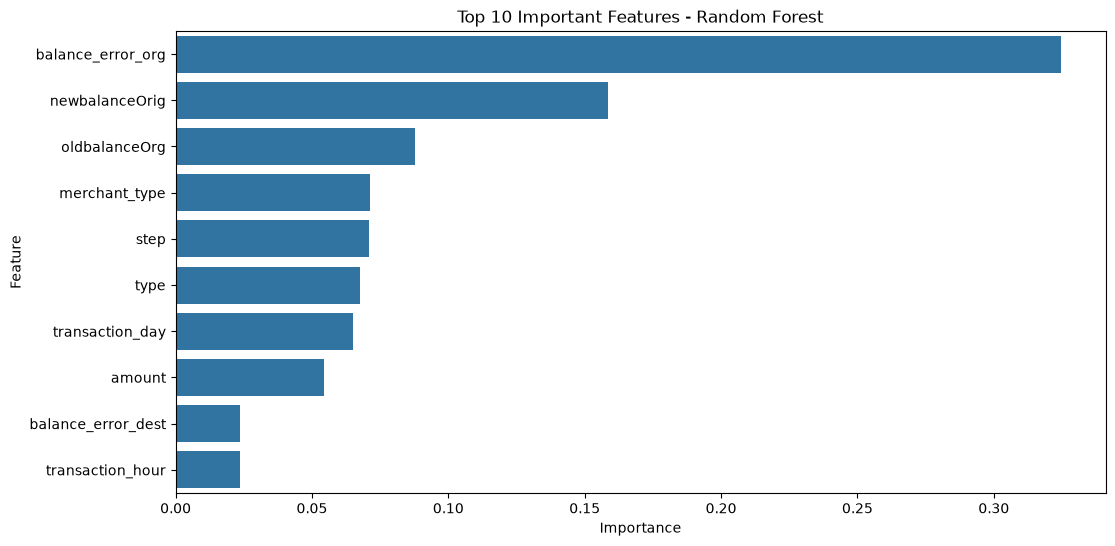

In [8]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Important Features - Random Forest"
)

plt.show()

In [9]:
# SHAP Explainability Analysis

shap_sample = X.sample(
    5000,
    random_state=42
)

print(shap_sample.shape)

(5000, 21)


In [10]:
explainer = shap.TreeExplainer(
    model
)

shap_values = explainer.shap_values(
    shap_sample
)

print(type(shap_values))
print(shap_values.shape)

<class 'numpy.ndarray'>
(5000, 21, 2)


In [11]:
shap_fraud = shap_values[:, :, 1]
print(shap_fraud.shape)

(5000, 21)


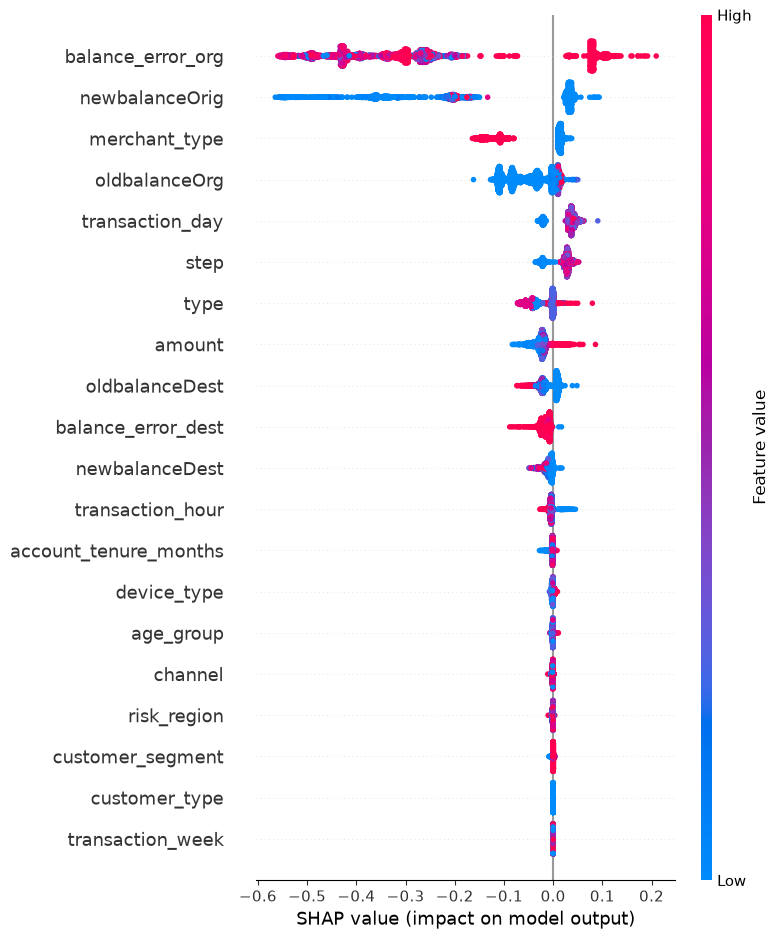

In [12]:
shap.summary_plot(
    shap_fraud,
    shap_sample
)

In [13]:
# SHAP Feature Importance

shap_importance = pd.DataFrame({
    "Feature": shap_sample.columns,
    "Mean_SHAP": np.abs(
        shap_fraud
    ).mean(axis=0)
})

shap_importance = (
    shap_importance
    .sort_values(
        by="Mean_SHAP",
        ascending=False
    )
)

shap_importance.head(15)

,Feature,Mean_SHAP
11,balance_error_org,0.297549
4,newbalanceOrig,0.142738
14,merchant_type,0.051698
3,oldbalanceOrg,0.047267
9,transaction_day,0.036131
0,step,0.028298
1,type,0.026702
2,amount,0.025606
5,oldbalanceDest,0.016641
12,balance_error_dest,0.015202


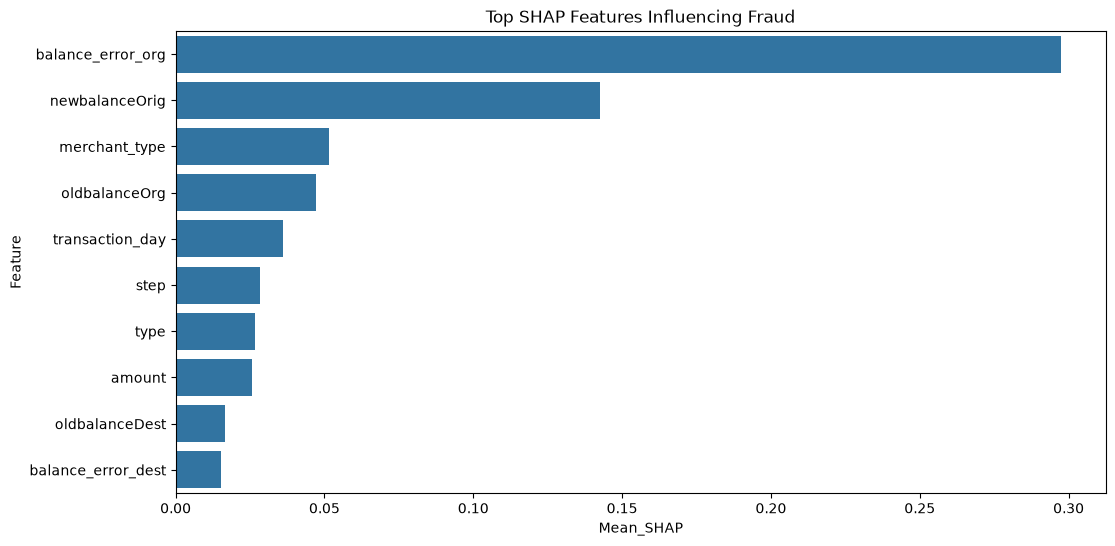

In [14]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=shap_importance.head(10),
    x="Mean_SHAP",
    y="Feature"
)

plt.title(
    "Top SHAP Features Influencing Fraud"
)

plt.show()

In [15]:
## Business Insights

top_features = (
    feature_importance
    .head(10)
)

top_features

print("Major Fraud Drivers")
print("1. Balance inconsistencies")
print("2. High-value transactions")
print("3. Transaction type")
print("4. Merchant-related transfers")
print("5. Account balance behavior")

Major Fraud Drivers
1. Balance inconsistencies
2. High-value transactions
3. Transaction type
4. Merchant-related transfers
5. Account balance behavior


## Operational Recommendations

1. Monitor large balance deviations.

2. Introduce additional verification for high-value transactions.

3. Apply enhanced monitoring to TRANSFER and CASH_OUT transactions.

4. Prioritize real-time fraud alerts for abnormal account balance activity.

5. Use explainability outputs during fraud investigations and compliance reviews.

In [16]:
# Export Explainability Reports

feature_importance.to_csv(
    "../reports/forest_feature_importance.csv",
    index=False
)

shap_importance.to_csv(
    "../reports/shap_feature_importance.csv",
    index=False
)

print("Explainability Reports Saved Successfully")

Explainability Reports Saved Successfully


## Conclusion

Feature importance and SHAP analysis identified balance-related variables, transaction amount, and transaction type as the primary fraud indicators.

The explainability framework provides transparency into model predictions and supports fraud investigations, risk assessment, audit requirements, and regulatory compliance.

The generated explainability reports will be used for business intelligence reporting and executive fraud analytics dashboards.